### Human In The Loop

In [18]:
import os
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DDD75B6600>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DDD6533020>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [19]:

from email import message
from json import tool
from typing import Annotated, TypedDict

from langchain_tavily import TavilySearch
from langgraph.graph import START, StateGraph, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command,interrupt
from langchain.tools import tool
from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
    messages : Annotated[list,add_messages]




@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query":query})
    return human_response["data"]


search_tool = TavilySearch(max_results=2)

tools = [search_tool,human_assistance]

llm_with_tools = llm.bind_tools(tools)

graph_builder = StateGraph(State)

def chatbot(state):
    message = llm_with_tools.invoke(state["messages"])
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_node)
graph_builder.add_conditional_edges(
    "chatbot",tools_condition
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")

In [20]:
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

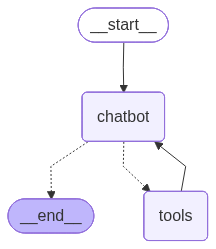

In [21]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [25]:
user_input = "I need some expert guidence and assistance for building an AI agent. Could you request assistance for me?"
config = {"configurable":{"thread_id":"1"}}

events =graph.stream(
    {"messages":user_input},
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidence and assistance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (w1hf1hyav)
 Call ID: w1hf1hyav
  Args:
    end_date: None
    exclude_domains: None
    include_domains: None
    include_images: True
    query: Expert guidance and assistance for building an AI agent
    search_depth: advanced
    start_date: None
    time_range: day
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "Expert guidance and assistance for building an AI agent", "follow_up_questions": null, "answer": null, "images": ["https://static.wixstatic.com/media/e6ecb9_70cf092a5bfe47beab47af17b1e35ad9~mv2.jpg/v1/fill/w_1024,h_768,al_c/e6ecb9_70cf092a5bfe47beab47af17b1e35ad9~mv2.jpg", "https://www.signitysoluti